# Anthropic KG Cookbook

notebook based on https://platform.claude.com/cookbook/capabilities-knowledge-graph-guide

related cookboks:

- Extracting structured JSON — the tool-use approach to the same extraction pattern, useful when you're already in an agentic tool-calling flow (https://github.com/anthropics/claude-cookbooks/blob/main/tool_use/extracting_structured_json.ipynb)
- Retrieval augmented generation — the complementary approach when you need document retrieval rather than fact traversal (https://github.com/anthropics/claude-cookbooks/blob/main/capabilities/retrieval_augmented_generation/guide.ipynb)
- Contextual embeddings — enriching chunks before embedding, the same "add context before indexing" idea applied to vector search (https://github.com/anthropics/claude-cookbooks/blob/main/capabilities/contextual-embeddings/guide.ipynb)


In [65]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [7]:
import json
import os
from collections import defaultdict
from pathlib import Path
from typing import Literal
from urllib.parse import quote
 
import anthropic
import matplotlib.pyplot as plt
import networkx as nx
import requests
from dotenv import load_dotenv
from pydantic import BaseModel

from pprint import pprint
 
load_dotenv()
client = anthropic.Anthropic(
    api_key=os.environ.get("ANTHROPIC_API_KEY"),  # This is the default and can be omitted
)
 
EXTRACTION_MODEL = "claude-haiku-4-5"
SYNTHESIS_MODEL = "claude-sonnet-4-6"

In [8]:
# We fetch summaries from the Wikipedia REST API rather than full articles to keep token costs low. 
# For a production pipeline you would chunk full documents; the extraction logic is identical.

ARTICLE_TITLES = [
    "Apollo program",
    "Apollo 11",
    "Neil Armstrong",
    "Saturn V",
    "Buzz Aldrin",
    "Kennedy Space Center",
]
 
WIKI_API = "https://en.wikipedia.org/api/rest_v1/page/summary/"
HEADERS = {"User-Agent": "claude-cookbooks/1.0 (https://github.com/anthropics/claude-cookbooks)"}


def fetch_summary(title: str) -> str:
    slug = quote(title.replace(" ", "_"), safe="")
    response = requests.get(WIKI_API + slug, headers=HEADERS, timeout=5)
    response.raise_for_status()

    return response.json()["extract"]

In [9]:
pprint(
    fetch_summary(ARTICLE_TITLES[0])
)

('The Apollo program, also known as Project Apollo, was the United States '
 'human spaceflight program led by NASA, which landed the first humans on the '
 'Moon in 1969. Apollo was conceived in 1960 in the Dwight D. Eisenhower '
 'presidency during Project Mercury and executed after Project Gemini. Apollo '
 'was later dedicated to President John F. Kennedy\'s national goal, "before '
 'this decade is out, of landing a man on the Moon and returning him safely to '
 'the Earth" in his address to the U.S. Congress on May 25, 1961.')


In [10]:
documents = []
for i, title in enumerate(ARTICLE_TITLES):
    try:
        documents.append({
            "id": i, 
            "title": title, 
            "text": fetch_summary(title)
        })
    except requests.RequestException as error:
        print(f"Skipping {title}: {error}")

if not documents:
    raise RuntimeError("No documents loaded - check network and Wiki API availability")

print(f"Loaded {len(documents)} documents")
print()
print(f"Sample: {documents[0]['title']}")
pprint(documents[0]["text"][:300])

Loaded 6 documents

Sample: Apollo program
('The Apollo program, also known as Project Apollo, was the United States '
 'human spaceflight program led by NASA, which landed the first humans on the '
 'Moon in 1969. Apollo was conceived in 1960 in the Dwight D. Eisenhower '
 'presidency during Project Mercury and executed after Project Gemini. Apollo '
 'was l')


In [11]:
import pickle

with open("documents.pkl", "wb") as file:
    pickle.dump(documents, file)

with open("documents.pkl", "rb") as docs:
    documents = pickle.load(docs)

In [13]:
# Entity and relation extraction
EntityType = Literal["PERSON", "ORGANIZATION", "LOCATION", "EVENT", "ARTIFACT"]
ENTITY_TYPES = ["PERSON", "ORGANIZATION", "LOCATION", "EVENT", "ARTIFACT"]
 
 
class Entity(BaseModel):
    name: str
    type: EntityType
    description: str
 
 
class Relation(BaseModel):
    source: str
    predicate: str
    target: str
 
 
class ExtractedGraph(BaseModel):
    entities: list[Entity]
    relations: list[Relation]
 
 
EXTRACTION_PROMPT = """Extract a knowledge graph from the document below.
 
<document>
{text}
</document>
 
Guidelines:
- Extract only entities that are central to what this document is about — skip incidental mentions.
- For each entity, write a one-sentence description grounded in this document. These descriptions are used later to disambiguate entities with similar names.
- Predicates should be short verb phrases ("commanded", "launched from", "part of").
- Every relation must connect two entities you extracted."""
 
 
def extract(text: str) -> ExtractedGraph:
    response = client.messages.parse(
        model=EXTRACTION_MODEL,
        max_tokens=1024,
        messages=[{
            "role": "user", 
            "content": EXTRACTION_PROMPT.format(text=text)
        }],
        output_format=ExtractedGraph,
    )
    return response.parsed_output

In [23]:
raw_entities  = []
raw_relations = []

for doc in documents:
    try:
        result = extract(doc["text"])
    except anthropic.APIError as error:
        print(f"Skipping {doc['title']}: {error}")
        continue

    for ent in result.entities:
        raw_entities.append({
            **ent.model_dump(), 
            "source_doc": doc["title"], 
        })
    for rel in result.relations:
        raw_relations.append({
            **rel.model_dump(), 
            "source_doc": doc["title"],
        })

    print(
        f"{doc['title']:<25} {len(result.entities):>3} entities  {len(result.relations):>3} relations"
    )
 
print(f"\nTotal: {len(raw_entities)} raw entities, {len(raw_relations)} raw relations")

Apollo program              7 entities    6 relations
Apollo 11                   6 entities    5 relations
Neil Armstrong              3 entities    3 relations
Saturn V                    6 entities    5 relations
Buzz Aldrin                 7 entities    8 relations
Kennedy Space Center       11 entities   10 relations

Total: 40 raw entities, 37 raw relations


In [27]:
pprint(raw_entities)

[{'description': 'A United States human spaceflight program led by NASA that '
                 'landed the first humans on the Moon in 1969.',
  'name': 'Apollo program',
  'source_doc': 'Apollo program',
  'type': 'EVENT'},
 {'description': 'The United States space agency that led the Apollo program.',
  'name': 'NASA',
  'source_doc': 'Apollo program',
  'type': 'ORGANIZATION'},
 {'description': 'The celestial body that was the destination of the Apollo '
                 "program's human landing missions.",
  'name': 'Moon',
  'source_doc': 'Apollo program',
  'type': 'LOCATION'},
 {'description': 'The U.S. President during whose administration Apollo was '
                 'conceived in 1960.',
  'name': 'Dwight D. Eisenhower',
  'source_doc': 'Apollo program',
  'type': 'PERSON'},
 {'description': 'The U.S. President who established the national goal of '
                 'landing a man on the Moon in his 1961 address to Congress.',
  'name': 'John F. Kennedy',
  'source_doc': 'A

In [14]:
raw_entities = [
    {'description': 'A United States human spaceflight program led by NASA that '
                 'landed the first humans on the Moon in 1969.',
  'name': 'Apollo program',
  'source_doc': 'Apollo program',
  'type': 'EVENT'},
 {'description': 'The United States space agency that led the Apollo program.',
  'name': 'NASA',
  'source_doc': 'Apollo program',
  'type': 'ORGANIZATION'},
 {'description': 'The celestial body that was the destination of the Apollo '
                 "program's human landing missions.",
  'name': 'Moon',
  'source_doc': 'Apollo program',
  'type': 'LOCATION'},
 {'description': 'The U.S. President during whose administration Apollo was '
                 'conceived in 1960.',
  'name': 'Dwight D. Eisenhower',
  'source_doc': 'Apollo program',
  'type': 'PERSON'},
 {'description': 'The U.S. President who established the national goal of '
                 'landing a man on the Moon in his 1961 address to Congress.',
  'name': 'John F. Kennedy',
  'source_doc': 'Apollo program',
  'type': 'PERSON'},
 {'description': 'A preceding United States human spaceflight program during '
                 'which Apollo was conceived in 1960.',
  'name': 'Project Mercury',
  'source_doc': 'Apollo program',
  'type': 'EVENT'},
 {'description': 'A United States human spaceflight program that occurred '
                 'before the execution of Apollo.',
  'name': 'Project Gemini',
  'source_doc': 'Apollo program',
  'type': 'EVENT'},
 {'description': 'The American spaceflight that first landed humans on the '
                 "Moon and was the fifth crewed mission of NASA's Apollo "
                 'program.',
  'name': 'Apollo 11',
  'source_doc': 'Apollo 11',
  'type': 'EVENT'},
 {'description': 'Commander of Apollo 11 who was on his second and final '
                 'spaceflight.',
  'name': 'Neil Armstrong',
  'source_doc': 'Apollo 11',
  'type': 'PERSON'},
 {'description': 'Command Module Pilot of Apollo 11 who was on his second and '
                 'final spaceflight.',
  'name': 'Michael Collins',
  'source_doc': 'Apollo 11',
  'type': 'PERSON'},
 {'description': 'Lunar Module Pilot of Apollo 11 who was on his second and '
                 'final spaceflight.',
  'name': 'Edwin Aldrin',
  'source_doc': 'Apollo 11',
  'type': 'PERSON'},
 {'description': 'The space agency that conducted the Apollo program and '
                 'Apollo 11 mission.',
  'name': 'NASA',
  'source_doc': 'Apollo 11',
  'type': 'ORGANIZATION'},
 {'description': 'The celestial body that was first reached by humans during '
                 'the Apollo 11 mission.',
  'name': 'Moon',
  'source_doc': 'Apollo 11',
  'type': 'LOCATION'},
 {'description': 'American astronaut and aeronautical engineer who became the '
                 'first person to walk on the Moon as commander of Apollo 11 '
                 'in 1969.',
  'name': 'Neil Alden Armstrong',
  'source_doc': 'Neil Armstrong',
  'type': 'PERSON'},
 {'description': 'The 1969 space mission during which Neil Armstrong became '
                 'the first person to walk on the Moon.',
  'name': 'Apollo 11',
  'source_doc': 'Neil Armstrong',
  'type': 'EVENT'},
 {'description': 'Celestial body that Neil Armstrong was the first person to '
                 'walk on during the Apollo 11 mission.',
  'name': 'Moon',
  'source_doc': 'Neil Armstrong',
  'type': 'LOCATION'},
 {'description': 'A retired American super heavy-lift launch vehicle developed '
                 'by NASA with three liquid-fueled stages used for human '
                 'exploration of the Moon.',
  'name': 'Saturn V',
  'source_doc': 'Saturn V',
  'type': 'ARTIFACT'},
 {'description': 'The organization that developed the Saturn V rocket under '
                 'the Apollo program.',
  'name': 'NASA',
  'source_doc': 'Saturn V',
  'type': 'ORGANIZATION'},
 {'description': 'The human space exploration program for which the Saturn V '
                 'was developed to enable missions to the Moon.',
  'name': 'Apollo program',
  'source_doc': 'Saturn V',
  'type': 'EVENT'},
 {'description': 'The launch facility from which all thirteen Saturn V '
                 'vehicles were launched between 1967 and 1973.',
  'name': 'Kennedy Space Center Launch Complex 39',
  'source_doc': 'Saturn V',
  'type': 'LOCATION'},
 {'description': 'The celestial body that was the destination for human '
                 'exploration missions enabled by Saturn V rockets.',
  'name': 'Moon',
  'source_doc': 'Saturn V',
  'type': 'LOCATION'},
 {'description': 'The first American space station that was launched by the '
                 "final Saturn V vehicle, converted from the rocket's third "
                 'stage.',
  'name': 'Skylab',
  'source_doc': 'Saturn V',
  'type': 'ARTIFACT'},
 {'description': 'An American former astronaut and aeronautical engineer who '
                 'was the second person to walk on the Moon and pilot of the '
                 'Lunar Module Eagle on Apollo 11.',
  'name': 'Buzz Aldrin',
  'source_doc': 'Buzz Aldrin',
  'type': 'PERSON'},
 {'description': 'The mission commander of Apollo 11 and the first person to '
                 'walk on the Moon.',
  'name': 'Neil Armstrong',
  'source_doc': 'Buzz Aldrin',
  'type': 'PERSON'},
 {'description': 'A pilot who was part of the Apollo 11 mission and died in '
                 '2021.',
  'name': 'Michael Collins',
  'source_doc': 'Buzz Aldrin',
  'type': 'PERSON'},
 {'description': 'The 1969 NASA mission on which Buzz Aldrin walked on the '
                 'Moon as Lunar Module Eagle pilot.',
  'name': 'Apollo 11',
  'source_doc': 'Buzz Aldrin',
  'type': 'EVENT'},
 {'description': 'A 1966 NASA mission on which Buzz Aldrin served as pilot and '
                 'made three spacewalks.',
  'name': 'Gemini 12',
  'source_doc': 'Buzz Aldrin',
  'type': 'EVENT'},
 {'description': 'The spacecraft module that Buzz Aldrin piloted during the '
                 'Apollo 11 mission.',
  'name': 'Lunar Module Eagle',
  'source_doc': 'Buzz Aldrin',
  'type': 'ARTIFACT'},
 {'description': 'The space agency that conducted the Gemini 12 and Apollo 11 '
                 'missions.',
  'name': 'NASA',
  'source_doc': 'Buzz Aldrin',
  'type': 'ORGANIZATION'},
 {'description': "NASA's primary launch center for American spaceflight, "
                 'research, and technology located on Merritt Island, Florida '
                 'since 1968.',
  'name': 'John F. Kennedy Space Center',
  'source_doc': 'Kennedy Space Center',
  'type': 'ORGANIZATION'},
 {'description': 'The space agency that operates the John F. Kennedy Space '
                 'Center as one of its ten field centers.',
  'name': 'NASA',
  'source_doc': 'Kennedy Space Center',
  'type': 'ORGANIZATION'},
 {'description': 'The location where the John F. Kennedy Space Center is '
                 'situated.',
  'name': 'Merritt Island, Florida',
  'source_doc': 'Kennedy Space Center',
  'type': 'LOCATION'},
 {'description': 'The launch facility at Kennedy Space Center from which '
                 'Apollo, Skylab, Space Shuttle, and Artemis programs were '
                 'launched.',
  'name': 'Launch Complex 39',
  'source_doc': 'Kennedy Space Center',
  'type': 'ARTIFACT'},
 {'description': 'A space program whose launch operations were carried out '
                 'from Kennedy Space Center Launch Complex 39.',
  'name': 'Apollo',
  'source_doc': 'Kennedy Space Center',
  'type': 'EVENT'},
 {'description': 'A space program whose launch operations were carried out '
                 'from Kennedy Space Center Launch Complex 39.',
  'name': 'Skylab',
  'source_doc': 'Kennedy Space Center',
  'type': 'EVENT'},
 {'description': 'A space program whose launch operations were carried out '
                 'from Kennedy Space Center Launch Complex 39.',
  'name': 'Space Shuttle',
  'source_doc': 'Kennedy Space Center',
  'type': 'EVENT'},
 {'description': 'A space program whose launch operations were carried out '
                 'from Kennedy Space Center Launch Complex 39.',
  'name': 'Artemis',
  'source_doc': 'Kennedy Space Center',
  'type': 'EVENT'},
 {'description': 'A space facility adjacent to Kennedy Space Center with which '
                 'KSC shares resources and operates facilities.',
  'name': 'Cape Canaveral Space Force Station',
  'source_doc': 'Kennedy Space Center',
  'type': 'ORGANIZATION'},
 {'description': 'The state on the east coast where Kennedy Space Center is '
                 'located.',
  'name': 'Florida',
  'source_doc': 'Kennedy Space Center',
  'type': 'LOCATION'},
 {'description': 'An island where Kennedy Space Center is located, situated on '
                 'the east coast of Florida.',
  'name': 'Merritt Island',
  'source_doc': 'Kennedy Space Center',
  'type': 'LOCATION'}]

In [29]:
raw_relations

[{'source': 'Apollo program',
  'predicate': 'led by',
  'target': 'NASA',
  'source_doc': 'Apollo program'},
 {'source': 'Apollo program',
  'predicate': 'landed humans on',
  'target': 'Moon',
  'source_doc': 'Apollo program'},
 {'source': 'Apollo program',
  'predicate': 'conceived during',
  'target': 'Project Mercury',
  'source_doc': 'Apollo program'},
 {'source': 'Apollo program',
  'predicate': 'executed after',
  'target': 'Project Gemini',
  'source_doc': 'Apollo program'},
 {'source': 'Apollo program',
  'predicate': 'dedicated to',
  'target': 'John F. Kennedy',
  'source_doc': 'Apollo program'},
 {'source': 'Dwight D. Eisenhower',
  'predicate': 'president during conception of',
  'target': 'Apollo program',
  'source_doc': 'Apollo program'},
 {'source': 'Apollo 11',
  'predicate': 'commanded by',
  'target': 'Neil Armstrong',
  'source_doc': 'Apollo 11'},
 {'source': 'Apollo 11',
  'predicate': 'crewed by',
  'target': 'Michael Collins',
  'source_doc': 'Apollo 11'},
 {'s

In [15]:
raw_relations = [{'source': 'Apollo program',
  'predicate': 'led by',
  'target': 'NASA',
  'source_doc': 'Apollo program'},
 {'source': 'Apollo program',
  'predicate': 'landed humans on',
  'target': 'Moon',
  'source_doc': 'Apollo program'},
 {'source': 'Apollo program',
  'predicate': 'conceived during',
  'target': 'Project Mercury',
  'source_doc': 'Apollo program'},
 {'source': 'Apollo program',
  'predicate': 'executed after',
  'target': 'Project Gemini',
  'source_doc': 'Apollo program'},
 {'source': 'Apollo program',
  'predicate': 'dedicated to',
  'target': 'John F. Kennedy',
  'source_doc': 'Apollo program'},
 {'source': 'Dwight D. Eisenhower',
  'predicate': 'president during conception of',
  'target': 'Apollo program',
  'source_doc': 'Apollo program'},
 {'source': 'Apollo 11',
  'predicate': 'commanded by',
  'target': 'Neil Armstrong',
  'source_doc': 'Apollo 11'},
 {'source': 'Apollo 11',
  'predicate': 'crewed by',
  'target': 'Michael Collins',
  'source_doc': 'Apollo 11'},
 {'source': 'Apollo 11',
  'predicate': 'crewed by',
  'target': 'Edwin Aldrin',
  'source_doc': 'Apollo 11'},
 {'source': 'Apollo 11',
  'predicate': 'part of',
  'target': 'NASA',
  'source_doc': 'Apollo 11'},
 {'source': 'Apollo 11',
  'predicate': 'landed on',
  'target': 'Moon',
  'source_doc': 'Apollo 11'},
 {'source': 'Neil Alden Armstrong',
  'predicate': 'commanded',
  'target': 'Apollo 11',
  'source_doc': 'Neil Armstrong'},
 {'source': 'Neil Alden Armstrong',
  'predicate': 'walked on',
  'target': 'Moon',
  'source_doc': 'Neil Armstrong'},
 {'source': 'Apollo 11',
  'predicate': 'landed on',
  'target': 'Moon',
  'source_doc': 'Neil Armstrong'},
 {'source': 'Saturn V',
  'predicate': 'developed by',
  'target': 'NASA',
  'source_doc': 'Saturn V'},
 {'source': 'Saturn V',
  'predicate': 'part of',
  'target': 'Apollo program',
  'source_doc': 'Saturn V'},
 {'source': 'Saturn V',
  'predicate': 'launched from',
  'target': 'Kennedy Space Center Launch Complex 39',
  'source_doc': 'Saturn V'},
 {'source': 'Saturn V',
  'predicate': 'enabled exploration of',
  'target': 'Moon',
  'source_doc': 'Saturn V'},
 {'source': 'Skylab',
  'predicate': 'launched by',
  'target': 'Saturn V',
  'source_doc': 'Saturn V'},
 {'source': 'Buzz Aldrin',
  'predicate': 'walked on the Moon during',
  'target': 'Apollo 11',
  'source_doc': 'Buzz Aldrin'},
 {'source': 'Buzz Aldrin',
  'predicate': 'piloted',
  'target': 'Lunar Module Eagle',
  'source_doc': 'Buzz Aldrin'},
 {'source': 'Neil Armstrong',
  'predicate': 'commanded',
  'target': 'Apollo 11',
  'source_doc': 'Buzz Aldrin'},
 {'source': 'Buzz Aldrin',
  'predicate': 'was pilot of',
  'target': 'Gemini 12',
  'source_doc': 'Buzz Aldrin'},
 {'source': 'Michael Collins',
  'predicate': 'was crew member of',
  'target': 'Apollo 11',
  'source_doc': 'Buzz Aldrin'},
 {'source': 'Buzz Aldrin',
  'predicate': 'was crew member of',
  'target': 'Apollo 11',
  'source_doc': 'Buzz Aldrin'},
 {'source': 'Apollo 11',
  'predicate': 'launched by',
  'target': 'NASA',
  'source_doc': 'Buzz Aldrin'},
 {'source': 'Gemini 12',
  'predicate': 'launched by',
  'target': 'NASA',
  'source_doc': 'Buzz Aldrin'},
 {'source': 'John F. Kennedy Space Center',
  'predicate': 'operated by',
  'target': 'NASA',
  'source_doc': 'Kennedy Space Center'},
 {'source': 'John F. Kennedy Space Center',
  'predicate': 'located on',
  'target': 'Merritt Island, Florida',
  'source_doc': 'Kennedy Space Center'},
 {'source': 'John F. Kennedy Space Center',
  'predicate': 'contains',
  'target': 'Launch Complex 39',
  'source_doc': 'Kennedy Space Center'},
 {'source': 'Apollo',
  'predicate': 'launched from',
  'target': 'Launch Complex 39',
  'source_doc': 'Kennedy Space Center'},
 {'source': 'Skylab',
  'predicate': 'launched from',
  'target': 'Launch Complex 39',
  'source_doc': 'Kennedy Space Center'},
 {'source': 'Space Shuttle',
  'predicate': 'launched from',
  'target': 'Launch Complex 39',
  'source_doc': 'Kennedy Space Center'},
 {'source': 'Artemis',
  'predicate': 'launched from',
  'target': 'Launch Complex 39',
  'source_doc': 'Kennedy Space Center'},
 {'source': 'John F. Kennedy Space Center',
  'predicate': 'adjacent to',
  'target': 'Cape Canaveral Space Force Station',
  'source_doc': 'Kennedy Space Center'},
 {'source': 'John F. Kennedy Space Center',
  'predicate': 'shares resources with',
  'target': 'Cape Canaveral Space Force Station',
  'source_doc': 'Kennedy Space Center'},
 {'source': 'Merritt Island, Florida',
  'predicate': 'located in',
  'target': 'Florida',
  'source_doc': 'Kennedy Space Center'}]

In [31]:
raw_entities[0]

{'description': 'A United States human spaceflight program led by NASA that landed the first humans on the Moon in 1969.',
 'name': 'Apollo program',
 'source_doc': 'Apollo program',
 'type': 'EVENT'}

In [16]:
by_type = defaultdict(list)
for e in raw_entities:
    by_type[e["type"]].append(e["name"])
 
for etype, names in sorted(by_type.items()):
    print(f"{etype} ({len(names)}):")
    for name in sorted(set(names)):
        print(f"  {name}")
    print()

ARTIFACT (4):
  Launch Complex 39
  Lunar Module Eagle
  Saturn V
  Skylab

EVENT (12):
  Apollo
  Apollo 11
  Apollo program
  Artemis
  Gemini 12
  Project Gemini
  Project Mercury
  Skylab
  Space Shuttle

LOCATION (8):
  Florida
  Kennedy Space Center Launch Complex 39
  Merritt Island
  Merritt Island, Florida
  Moon

ORGANIZATION (7):
  Cape Canaveral Space Force Station
  John F. Kennedy Space Center
  NASA

PERSON (9):
  Buzz Aldrin
  Dwight D. Eisenhower
  Edwin Aldrin
  John F. Kennedy
  Michael Collins
  Neil Alden Armstrong
  Neil Armstrong



In [20]:
# Entity Resolution

class Cluster(BaseModel):
    canonical: str
    aliases: list[str]
 
 
class ResolvedClusters(BaseModel):
    clusters: list[Cluster]
 
 
RESOLVE_PROMPT = """Below are {entity_type} entities extracted from several documents. 
Some are different surface forms of the same real-world entity.
 
<entities>
{entity_list}
</entities>
 
Cluster them. Each input name must appear in exactly one cluster's aliases list. 
Entities that are genuinely distinct get their own single-element cluster. U
Use the descriptions to avoid merging entities that merely share a name. 
The canonical name should be the most complete, unambiguous form."""
 

def build_entity_list(entities: list[dict]):
    unique = {}
    for e in entities:
        unique.setdefault(e["name"], e["description"])
    entity_list = "\n".join(f"- {name}: {desc}" for name, desc in unique.items())
    return entity_list

def resolve(entity_type: str, entities: list[dict]) -> list[Cluster]:
    unique = {}
    for e in entities:
        unique.setdefault(e["name"], e["description"])
    entity_list = build_entity_list(entities)
 
    response = client.messages.parse(
        model=SYNTHESIS_MODEL,
        max_tokens=1024,
        messages=[
            {
                "role": "user",
                "content": RESOLVE_PROMPT.format(entity_type=entity_type, entity_list=entity_list),
            }
        ],
        output_format=ResolvedClusters,
    )
    return response.parsed_output.clusters

In [19]:
raw_entities[0]

{'description': 'A United States human spaceflight program led by NASA that landed the first humans on the Moon in 1969.',
 'name': 'Apollo program',
 'source_doc': 'Apollo program',
 'type': 'EVENT'}

In [28]:
alias_to_canonical    = {}
canonical_information = {}

for etype in ENTITY_TYPES:
    entities_of_type = [e for e in raw_entities if e["type"] == etype]
    if not entities_of_type:
        continue
    try: 
        clusters = resolve(etype, entities_of_type)
        # [Cluster(canonical='Dwight D. Eisenhower', aliases=['Dwight D. Eisenhower']),
        #  Cluster(canonical='Edwin Aldrin', aliases=['Edwin Aldrin']),
        #  Cluster(canonical='Buzz Aldrin', aliases=['Buzz Aldrin']),
        #  Cluster(canonical='Michael Collins', aliases=['Michael Collins']),
        #  Cluster(canonical='Neil Armstrong', aliases=['Neil Armstrong']),
        #  Cluster(canonical='John F. Kennedy', aliases=['John F. Kennedy']),
        #  Cluster(canonical='Neil Alden Armstrong', aliases=['Neil Alden Armstrong'])]
    except anthropic.APIError as e:
        print(f"Resolve failed for {etype}: {e}; treating each name as its own cluster")
        clusters = [
            Cluster(canonical=n, aliases=[n]) for n in {x["name"] for x in entities_of_type}
        ]
    for cluster in clusters:
        canonical_information[cluster.canonical] = {"type": etype, "aliases": cluster.aliases}
        for alias in cluster.aliases:
            alias_to_canonical[alias] = cluster.canonical

before = len({e["name"] for e in raw_entities})
after = len(canonical_information)
print(f"Entity resolution: {before} unique names → {after} canonical entities\n")

Entity resolution: 27 unique names → 23 canonical entities



In [30]:
canonical_information['Dwight D. Eisenhower']

{'type': 'PERSON', 'aliases': ['Dwight D. Eisenhower']}

In [31]:
for canonical, info in sorted(canonical_information.items()):
    aliases = [a for a in info["aliases"] if a != canonical]
    alias_str = f"  (also: {', '.join(aliases)})" if aliases else ""
    print(f"{info['type']:<14} {canonical}{alias_str}")

EVENT          Apollo 11
EVENT          Apollo program  (also: Apollo)
EVENT          Artemis program  (also: Artemis)
PERSON         Buzz Aldrin  (also: Edwin Aldrin)
ORGANIZATION   Cape Canaveral Space Force Station
PERSON         Dwight D. Eisenhower
LOCATION       Florida
EVENT          Gemini 12
PERSON         John F. Kennedy
ORGANIZATION   John F. Kennedy Space Center
LOCATION       Kennedy Space Center Launch Complex 39
ARTIFACT       Launch Complex 39
ARTIFACT       Lunar Module Eagle
LOCATION       Merritt Island, Florida  (also: Merritt Island)
PERSON         Michael Collins
LOCATION       Moon
ORGANIZATION   NASA
PERSON         Neil Alden Armstrong  (also: Neil Armstrong)
EVENT          Project Gemini
EVENT          Project Mercury
ARTIFACT       Saturn V
ARTIFACT       Skylab
EVENT          Space Shuttle


In [32]:
alias_to_canonical

{'Dwight D. Eisenhower': 'Dwight D. Eisenhower',
 'John F. Kennedy': 'John F. Kennedy',
 'Neil Armstrong': 'Neil Alden Armstrong',
 'Neil Alden Armstrong': 'Neil Alden Armstrong',
 'Michael Collins': 'Michael Collins',
 'Edwin Aldrin': 'Buzz Aldrin',
 'Buzz Aldrin': 'Buzz Aldrin',
 'NASA': 'NASA',
 'John F. Kennedy Space Center': 'John F. Kennedy Space Center',
 'Cape Canaveral Space Force Station': 'Cape Canaveral Space Force Station',
 'Moon': 'Moon',
 'Kennedy Space Center Launch Complex 39': 'Kennedy Space Center Launch Complex 39',
 'Merritt Island, Florida': 'Merritt Island, Florida',
 'Merritt Island': 'Merritt Island, Florida',
 'Florida': 'Florida',
 'Apollo program': 'Apollo program',
 'Apollo': 'Apollo program',
 'Project Mercury': 'Project Mercury',
 'Project Gemini': 'Project Gemini',
 'Apollo 11': 'Apollo 11',
 'Gemini 12': 'Gemini 12',
 'Skylab': 'Skylab',
 'Space Shuttle': 'Space Shuttle',
 'Artemis': 'Artemis program',
 'Saturn V': 'Saturn V',
 'Lunar Module Eagle': 'L

In [33]:
raw_entities[0]

{'description': 'A United States human spaceflight program led by NASA that landed the first humans on the Moon in 1969.',
 'name': 'Apollo program',
 'source_doc': 'Apollo program',
 'type': 'EVENT'}

In [34]:
# Assembling the graph
# We use a MultiDiGraph because two entities can be connected by several distinct predicates ("launched from" and "operated by"), 
# and direction matters ("Armstrong commanded Apollo 11" is not the same edge as "Apollo 11 commanded Armstrong").

G = nx.MultiDiGraph()

for e in raw_entities:
    canonical = alias_to_canonical.get(e["name"])
    if canonical is None:
        continue
    if canonical not in G:
        G.add_node(
            canonical, 
            type=canonical_information[canonical]["type"], 
            description=e["description"], 
            source_docs=[], 
            mentions=0
        )
    G.nodes[canonical]["source_docs"].append(e["source_doc"])
    G.nodes[canonical]["mentions"] += 1

In [40]:
pprint(G.nodes)
print()
pprint(G.nodes["Apollo program"])

NodeView(('Apollo program', 'NASA', 'Moon', 'Dwight D. Eisenhower', 'John F. Kennedy', 'Project Mercury', 'Project Gemini', 'Apollo 11', 'Neil Alden Armstrong', 'Michael Collins', 'Buzz Aldrin', 'Saturn V', 'Kennedy Space Center Launch Complex 39', 'Skylab', 'Gemini 12', 'Lunar Module Eagle', 'John F. Kennedy Space Center', 'Merritt Island, Florida', 'Launch Complex 39', 'Space Shuttle', 'Artemis program', 'Cape Canaveral Space Force Station', 'Florida'))

{'description': 'A United States human spaceflight program led by NASA that '
                'landed the first humans on the Moon in 1969.',
 'mentions': 3,
 'source_docs': ['Apollo program', 'Saturn V', 'Kennedy Space Center'],
 'type': 'EVENT'}


In [41]:
raw_relations[0]

{'source': 'Apollo program',
 'predicate': 'led by',
 'target': 'NASA',
 'source_doc': 'Apollo program'}

In [42]:
for r in raw_relations:
    src = alias_to_canonical.get(r["source"])
    tgt = alias_to_canonical.get(r["target"])
    if src and tgt and src != tgt: 
        G.add_edge(
            src, tgt, 
            predicate=r["predicate"], 
            source_doc=r["source_doc"]
        )

for node in G.nodes:
    G.nodes[node]["source_docs"] = sorted(set(G.nodes[node]["source_docs"]))

In [43]:
print(f"Graph: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")
print(f"Connected components: {nx.number_weakly_connected_components(G)}")
print("\nMost connected entities:")
for node, deg in sorted(G.degree(), key=lambda x: -x[1])[:5]:
    print(f"  {node:<35} degree {deg:>2}  ({G.nodes[node]['type']})")

Graph: 23 nodes, 37 edges
Connected components: 1

Most connected entities:
  Apollo 11                           degree 12  (EVENT)
  Apollo program                      degree  8  (EVENT)
  NASA                                degree  6  (ORGANIZATION)
  Moon                                degree  5  (LOCATION)
  Buzz Aldrin                         degree  5  (PERSON)


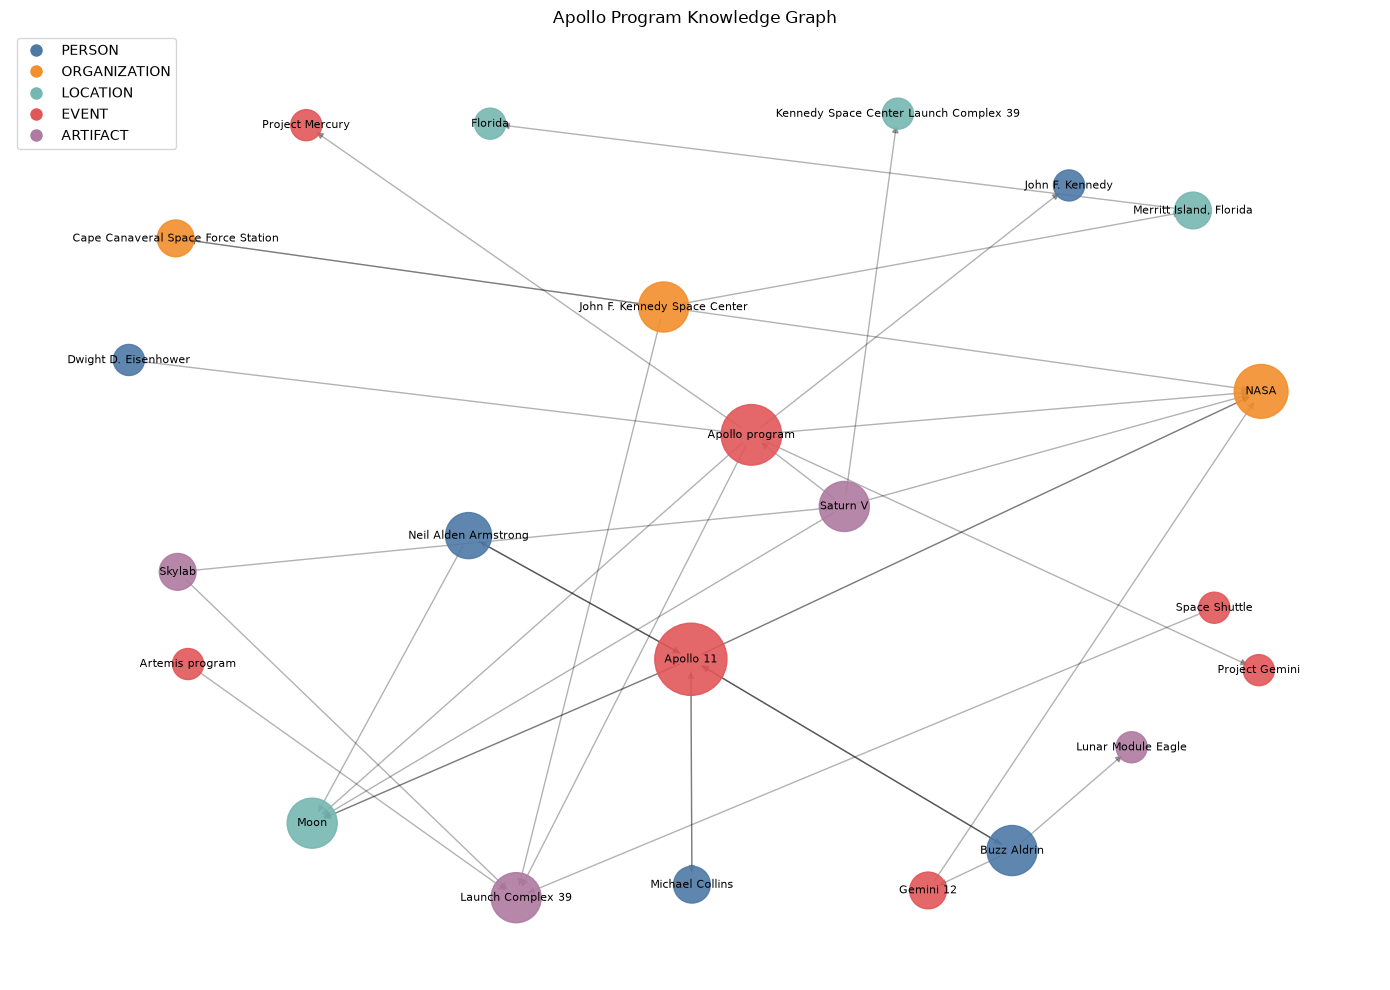

In [44]:
COLOR = {
    "PERSON": "#4e79a7",
    "ORGANIZATION": "#f28e2c",
    "LOCATION": "#76b7b2",
    "EVENT": "#e15759",
    "ARTIFACT": "#af7aa1",
}
 
plt.figure(figsize=(14, 10))
pos = nx.spring_layout(G, k=1.5, seed=42)
node_colors = [COLOR[G.nodes[n]["type"]] for n in G.nodes]
node_sizes = [300 + 200 * G.degree(n) for n in G.nodes]
 
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=8)
nx.draw_networkx_edges(G, pos, alpha=0.3, arrows=True, arrowsize=10)
 
handles = [
    plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=10, label=t)
    for t, c in COLOR.items()
    if any(G.nodes[n]["type"] == t for n in G.nodes)
]
plt.legend(handles=handles, loc="upper left")
plt.title("Apollo Program Knowledge Graph")
plt.axis("off")
plt.tight_layout()
plt.show()

In [45]:
pprint(G.nodes["Apollo program"])

{'description': 'A United States human spaceflight program led by NASA that '
                'landed the first humans on the Moon in 1969.',
 'mentions': 3,
 'source_docs': ['Apollo program', 'Kennedy Space Center', 'Saturn V'],
 'type': 'EVENT'}


In [46]:
# Entity summarization
# This is the step that turns a graph of labels into a graph of knowledge.

class TimeRange(BaseModel):
    start: str  # YYYY or YYYY-MM, or "unknown"
    end: str  # YYYY or YYYY-MM, or "ongoing"
 
 
class EntityProfile(BaseModel):
    summary: str
    key_facts: list[str]
    time_range: TimeRange
 
 
SUMMARIZE_PROMPT = """Generate a knowledge-graph profile for this entity.
 
Entity: {name} ({etype})
 
Source excerpts mentioning this entity:
{excerpts}
 
Known relations in the graph:
{relations}
 
Write a 2-3 paragraph factual summary synthesized from the excerpts, resolving any contradictions by preferring the most specific claim. Include 3-5 atomic key facts, each traceable to the sources. For the time range, use YYYY or YYYY-MM format, or "unknown"/"ongoing" where appropriate. Do not invent facts not supported by the excerpts."""
 
 
def summarize_entity(name: str) -> EntityProfile:
    # Reads module-level G and documents built earlier in the notebook.
    docs_with_entity = G.nodes[name]["source_docs"]
    excerpts = "\n\n".join(
        f"[{d['title']}]\n{d['text']}" for d in documents if d["title"] in docs_with_entity
    )
    relations = (
        "\n".join(
            f"- {name} --{d['predicate']}--> {tgt}" for _, tgt, d in G.out_edges(name, data=True)
        )
        + "\n"
        + "\n".join(
            f"- {src} --{d['predicate']}--> {name}" for src, _, d in G.in_edges(name, data=True)
        )
    )
 
    response = client.messages.parse(
        model=SYNTHESIS_MODEL,
        max_tokens=1024,
        messages=[
            {
                "role": "user",
                "content": SUMMARIZE_PROMPT.format(
                    name=name, etype=G.nodes[name]["type"], excerpts=excerpts, relations=relations
                ),
            }
        ],
        output_format=EntityProfile,
    )
    return response.parsed_output

In [54]:
hub_nodes = [n for n, _ in sorted(G.degree(), key=lambda x: -x[1])[:3]]
# [('Apollo 11', 12),
#  ('Apollo program', 8),
#  ('NASA', 6),
#  ('Moon', 5),
#  ('Buzz Aldrin', 5),
#  ('Saturn V', 5),
#  ('John F. Kennedy Space Center', 5),
#  ('Launch Complex 39', 5),
#  ('Neil Alden Armstrong', 4),
#  ('Michael Collins', 2),
#  ('Skylab', 2),
#  ('Gemini 12', 2),
#  ('Merritt Island, Florida', 2),
#  ('Cape Canaveral Space Force Station', 2),
#  ('Dwight D. Eisenhower', 1),
#  ('John F. Kennedy', 1),
#  ('Project Mercury', 1),
#  ('Project Gemini', 1),
#  ('Kennedy Space Center Launch Complex 39', 1),
#  ('Lunar Module Eagle', 1),
#  ('Space Shuttle', 1),
#  ('Artemis program', 1),
#  ('Florida', 1)]

In [55]:
for node in hub_nodes:
    profile = summarize_entity(node)
    G.nodes[node]["profile"] = profile.model_dump()
    print(f"═══ {node} ═══")
    print(profile.summary)
    print(f"\nTime range: {profile.time_range.start} – {profile.time_range.end}")
    print("Key facts:")
    for fact in profile.key_facts:
        print(f"  • {fact}")
    print()

═══ Apollo 11 ═══
Apollo 11 was the American spaceflight that achieved the first crewed lunar landing, representing the fifth crewed mission of NASA's Apollo program. The mission was commanded by Neil Armstrong, with Michael Collins serving as Command Module Pilot and Edwin "Buzz" Aldrin as Lunar Module Pilot. All three crew members were on their second and final spaceflights.

The mission is historically significant as it resulted in Neil Armstrong becoming the first person to walk on the Moon, followed by Buzz Aldrin as the second. Michael Collins remained in lunar orbit aboard the Command Module while Armstrong and Aldrin descended to the lunar surface. The mission was launched and operated by NASA in 1969.

Of the three crew members, Buzz Aldrin is the last surviving member of the Apollo 11 crew, following the deaths of Neil Armstrong in 2012 and Michael Collins in 2021. Aldrin is also recognized as the oldest living astronaut.

Time range: 1969 – 1969
Key facts:
  • Apollo 11 was 

In [60]:
# Querying the graph

def serialize_subgraph(center: str, hops: int = 2) -> str:
    nodes = {center}
    frontier = {center}
    for _ in range(hops):
        nxt = set()
        for n in frontier:
            nxt |= set(G.successors(n)) | set(G.predecessors(n))
        frontier = nxt - nodes
        nodes |= frontier
    sub = G.subgraph(nodes)
    lines = [f"({s}) --[{d['predicate']}]--> ({t})" for s, t, d in sub.edges(data=True)]
    return "\n".join(sorted(set(lines)))
 
 
def ask(question: str, graph_context: str | None = None) -> str:
    if graph_context is not None:
        prompt = f"""Answer using only the knowledge graph below. Cite the specific edges that support your answer.
 
<graph>
{graph_context}
</graph>
 
Question: {question}"""
    else:
        prompt = question
    response = client.messages.create(
        model=SYNTHESIS_MODEL,
        max_tokens=500,
        messages=[{"role": "user", "content": prompt}],
    )
    text_block = next((b for b in response.content if b.type == "text"), None)
    if text_block is None:
        raise ValueError(f"No text block in response (stop_reason={response.stop_reason})")
    return text_block.text

In [61]:
center = next((n for n in G.nodes if "Apollo" in n), hub_nodes[0])
center

'Apollo program'

In [63]:
print(f"Querying 2-hop neighborhood of: {center}\n")
subgraph = serialize_subgraph(center, hops=2)
pprint(subgraph)

Querying 2-hop neighborhood of: Apollo program

('(Apollo 11) --[commanded by]--> (Neil Alden Armstrong)\n'
 '(Apollo 11) --[landed on]--> (Moon)\n'
 '(Apollo 11) --[launched by]--> (NASA)\n'
 '(Apollo 11) --[part of]--> (NASA)\n'
 '(Apollo program) --[conceived during]--> (Project Mercury)\n'
 '(Apollo program) --[dedicated to]--> (John F. Kennedy)\n'
 '(Apollo program) --[executed after]--> (Project Gemini)\n'
 '(Apollo program) --[landed humans on]--> (Moon)\n'
 '(Apollo program) --[launched from]--> (Launch Complex 39)\n'
 '(Apollo program) --[led by]--> (NASA)\n'
 '(Artemis program) --[launched from]--> (Launch Complex 39)\n'
 '(Dwight D. Eisenhower) --[president during conception of]--> (Apollo '
 'program)\n'
 '(Gemini 12) --[launched by]--> (NASA)\n'
 '(John F. Kennedy Space Center) --[contains]--> (Launch Complex 39)\n'
 '(John F. Kennedy Space Center) --[operated by]--> (NASA)\n'
 '(Neil Alden Armstrong) --[commanded]--> (Apollo 11)\n'
 '(Neil Alden Armstrong) --[walked on]--

In [64]:
question = "Which locations are connected to people who were part of Apollo 11, and how?"
 
print("WITHOUT graph context:")
print(ask(question))
print("\n" + "─" * 60 + "\n")
print("WITH graph context:")
print(ask(question, subgraph))

WITHOUT graph context:
# Apollo 11 Crew: Location Connections

## Neil Armstrong

| Location | Connection |
|----------|------------|
| Wapakoneta, Ohio | Birthplace and hometown; National Museum there honors him |
| Purdue University, Indiana | Earned his BS in Aeronautical Engineering |
| Edwards Air Force Base, California | Served as test pilot |
| Houston, Texas | Based at NASA's Manned Spacecraft Center |
| Lebanon, Ohio | Lived there later in life |

## Buzz Aldrin

| Location | Connection |
|----------|------------|
| Montclair, New Jersey | Birthplace |
| West Point, New York | Graduated from the US Military Academy |
| MIT, Cambridge, Massachusetts | Earned his doctorate |
| Edwards Air Force Base, California | Test pilot service |
| Los Angeles, California | Long-time residence |

## Michael Collins

| Location | Connection |
|----------|------------|
| Rome, Italy | Birthplace |
| Washington, D.C. | Grew up there; later directed the Smithsonian Air and Space Museum |
| West 

In [ ]:
# Evaluation
# Knowledge graph quality is measured with precision and recall against a gold set.

# uv run python capabilities/knowledge_graph/evaluation/eval_extraction.py

# Expects the kernel launched from this notebook's directory
# (capabilities/knowledge_graph/). Falls back to repo root.
data_dir = Path("data")
if not data_dir.exists():
    data_dir = Path("capabilities/knowledge_graph/data")
 
with open(data_dir / "sample_triples.json", encoding="utf-8") as f:
    gold = json.load(f)
with open(data_dir / "alias_map.json", encoding="utf-8") as f:
    ALIASES = json.load(f)
 
 
def norm(name: str) -> str:
    lower = name.lower().strip()
    return ALIASES.get(lower, lower)
 
 
def prf(predicted: set, gold: set) -> tuple[float, float, float]:
    tp = len(predicted & gold)
    p = tp / len(predicted) if predicted else 0.0
    r = tp / len(gold) if gold else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) else 0.0
    return p, r, f1
 
 
print("Raw extraction vs resolved-graph recall against gold:\n")
for doc_title, labels in gold.items():
    gold_names = {norm(e["name"]) for e in labels["entities"]}
 
    raw = {norm(e["name"]) for e in raw_entities if e["source_doc"] == doc_title}
    rp, rr, rf = prf(raw, gold_names)
 
    resolved = {
        norm(alias_to_canonical.get(e["name"], e["name"]))
        for e in raw_entities
        if e["source_doc"] == doc_title
    }
    _, resolved_r, _ = prf(resolved, gold_names)
 
    print(f"{doc_title:<20}  raw F1={rf:.2f} (P={rp:.2f} R={rr:.2f})  resolved R={resolved_r:.2f}")
    missed = gold_names - resolved
    if missed:
        print(f"  still missed after resolution: {', '.join(sorted(missed))}")